## Final test evaluation

Refit the selected model family on all permitted development data, transform the 2021 test set with that same fitted pipeline, evaluate once and save atifacts.

In [3]:
from pathlib import Path
import sys
import json
import platform
import time
import joblib
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

def find_project_root(start: Path = Path.cwd()) -> Path:
    """Find the parent directory containing src/data.py."""
    for candidate in (start, *start.parents):
        if (candidate / "src" / "data.py").is_file():
            return candidate

    raise FileNotFoundError("Could not find src/data.py")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
    
from config import ProjectConfig, ProjectPaths

config = ProjectConfig()
paths = ProjectPaths(PROJECT_ROOT)
paths.ensure_output_dirs

from modeling import (
    build_model_pipeline
    ,chronological_split
    ,development_and_test_split
    ,make_xy
    ,save_json
    ,select_recent_dates
    ,evaluate_predictions
    ,walk_forward_split
    ,make_fold_metric_record
)
from features import (
    infer_feature_columns
)


print("Project root:", PROJECT_ROOT)
print("Imported load_data successfully")

print("Imported libraries sucessfully! yay")

Project root: c:\Users\MY NGOC\Documents\MAU_TACAS_68803\DA631E_ArtificialIntelligenceForDataScience\Project_1_SupervisedLearning
Imported load_data successfully
Imported libraries sucessfully! yay


In [4]:
selected_path = paths.reports / "selected_model.json"
if not selected_path.is_file():
    raise FileNotFoundError("Run notebook 04 and save the model family first")

selection = json.loads(selected_path.read_text(encoding='utf-8'))
selected_model = selection['selected_model']
FAST_MODE = bool(selection['fast_mode'])
print(f"Selected model: {selected_model}; FAST_MODE={FAST_MODE}")

Selected model: hist_gradient_boosting; FAST_MODE=False


### Rebuild development data (train + validation) and test sets

Train and validation datasets are now combined becuase the model is fixed. Use the combined set to train and no longer need a purge between train and validation.

The final two development dates are purged because their labels cross into the 2021 test period

In [6]:
features_table = pd.read_parquet(paths.processed / "features_table.parquet")
numeric_features, categorical_features = infer_feature_columns(features_table)
development, test, purged_dates = development_and_test_split(features_table, config)

split_summary = pd.DataFrame({
    'split': ["development","test"]
    ,'rows': [len(development), len(test)]
    ,'dates': [development['Date'].nunique(), test['Date'].nunique()]
    ,'date_min': [development['Date'].min(), test['Date'].min()]
    ,'date_max': [development['Date'].max(), test['Date'].max()]
}).set_index('split')
display(split_summary)

print("Purged before test: ", [str(date.date()) for date in purged_dates])

,rows,dates,date_min,date_max
split,,,,
development,1876293,974,2017-01-04,2020-12-28
test,452000,226,2021-01-04,2021-12-03


Purged before test:  ['2020-12-29', '2020-12-30']


### Fit on development and transform test

In [7]:
X_development, y_development = make_xy(development, numeric_features, categorical_features)
X_test, y_test = make_xy(test, numeric_features, categorical_features)

pipeline = build_model_pipeline(
    model_name = selected_model
    ,numeric_features= numeric_features
    ,categorical_features= categorical_features
    ,random_seed = config.random_seed
    ,fast_mode= FAST_MODE)

started = time.perf_counter()
pipeline.fit(X_development, y_development)
fit_seconds = time.perf_counter() - started

test_predictions = pipeline.predict(X_test)
assert len(test_predictions) == len(test)
assert np.isfinite(test_predictions).all()

print(f"Final fit completed in {fit_seconds:1f} seconds")

Final fit completed in 45.778905 seconds


### Open test result

Interpret ranking metrics

In [9]:
test_metrics, test_ranked, test_daily_ic, test_daily_spread_return = evaluate_predictions(
    df = test
    ,predictions = test_predictions
    ,config=config
    ,strict_portfolio_size = True
)
test_metrics.loc['FinalFitSeconds'] = fit_seconds

display(test_metrics.to_frame())

,value
MAE,0.015190
RMSE,0.000488
R2,-0.011270
MeanDailyIC,0.004303
MedianDailyIC,0.004393
MeanDailySpreadReturn,0.150821
MedianDailySpreadReturn,0.122701
DailySpreadReturnStd,1.707377
SpreadSharpeRatio,0.088335
FinalFitSeconds,45.778905


In [11]:
rank_check = test_ranked.groupby('Date')['Rank'].agg(['min','max','nunique','size'])
assert rank_check['min'].eq(0).all()
assert rank_check['nunique'].eq(rank_check['size']).all()
assert rank_check['max'].eq(rank_check['size'] - 1).all()

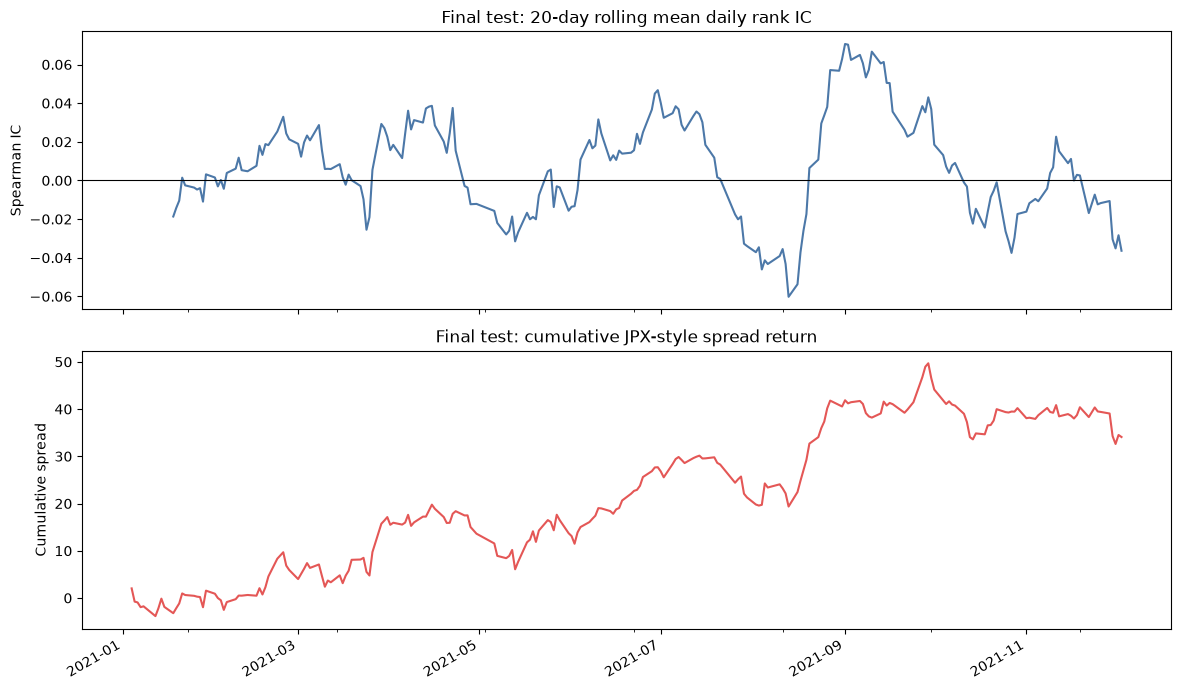

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
test_daily_ic.rolling(20, min_periods=10).mean().plot(ax=axes[0], color="#4C78A8")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Final test: 20-day rolling mean daily rank IC")
axes[0].set_ylabel("Spearman IC")

test_daily_spread_return.cumsum().plot(ax=axes[1], color="#E45756")
axes[1].set_title("Final test: cumulative JPX-style spread return")
axes[1].set_ylabel("Cumulative spread")
plt.tight_layout()
plt.show()

In [14]:
monthly_ic = test_daily_ic.groupby(test_daily_ic.index.to_period("M")).agg(["mean", "median", "count"])
quarterly_spread = test_daily_spread_return.groupby(test_daily_spread_return.index.to_period("Q")).agg(
    ["mean", "std", "sum", "count"]
)
quarterly_spread["Sharpe"] = quarterly_spread["mean"] / quarterly_spread["std"]
display(monthly_ic)
display(quarterly_spread)

,mean,median,count
2021-01,0.003170,-0.018549,19
2021-02,0.016552,0.016724,18
2021-03,0.022548,0.037783,23
2021-04,-0.015160,-0.006031,21
2021-05,-0.005434,-0.014461,18
2021-06,0.034810,0.041793,22
2021-07,-0.033924,-0.040307,20
2021-08,0.052402,0.050958,21
2021-09,0.036875,0.022702,20
2021-10,-0.026668,-0.028807,21


,mean,std,sum,count,Sharpe
2021Q1,0.285498,1.846913,17.129905,60,0.154581
2021Q2,0.173035,1.594489,10.555115,61,0.108520
2021Q3,0.309120,1.795666,18.856298,61,0.172148
2021Q4,-0.283087,1.507435,-12.455824,44,-0.187794
